In [1]:
# Install required packages
!pip install -q kagglehub shap scikit-learn seaborn

In [2]:
#  Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import shap
import time
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, mean_absolute_error, r2_score,
    precision_score, recall_score, f1_score
)

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import plot_model

print("Imports done.")

Imports done.


In [3]:
#  Download dataset
path = kagglehub.dataset_download("derrickmwiti/google-2019-cluster-sample")
print("Dataset path:", path)

# Load data
data = pd.read_csv(f"{path}/borg_traces_data.csv")
print("Initial shape:", data.shape)
display(data.head())

100%|██████████| 96.7M/96.7M [00:00<00:00, 206MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/derrickmwiti/google-2019-cluster-sample/versions/1
Initial shape: (405894, 34)


,Unnamed: 0,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,...,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cpu_usage_distribution,tail_cpu_usage_distribution,cluster,event,failed
0,0,0,2,94591244395,3,1,200,0,144,168846390496,...,0.014435,0.000415,NaN,NaN,1.0,[0.00314331 0.00381088 0.00401306 0.00415039 0...,[0.00535583 0.00541687 0.00548553 0.00554657 0...,7,FAIL,1
1,1,2517305308183,2,260697606809,2,0,360,221495397286,335,85515092,...,0.000000,0.000000,NaN,NaN,1.0,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,7,FAIL,1
2,2,195684022913,6,276227177776,2,0,103,0,376,169321752432,...,0.010422,0.000235,0.939919,0.001318,1.0,[0.01344299 0.01809692 0.0201416 0.02246094 0...,[0.02902222 0.02929688 0.0295105 0.0296936 0...,7,SCHEDULE,0
3,3,0,2,10507389885,3,0,200,0,1977,178294817221,...,0.041626,0.000225,1.359102,0.007643,1.0,[0.03704834 0.04125977 0.04290771 0.04425049 0...,[0.05535889 0.05584717 0.05633545 0.05718994 0...,8,FAIL,1
4,4,1810627494172,3,25911621841,2,0,0,0,3907,231364893292,...,0.000272,0.000010,NaN,NaN,1.0,[0. 0. 0. 0. 0...,[0.00041485 0.00041485 0.00041485 0.00041485 0...,2,FINISH,0


In [4]:
# Basic info and cleaning like original
print("\nData info:")
display(data.info())

# Drop Unnamed: 0 if exists, select numeric, remove *_id columns, drop NA
if 'Unnamed: 0' in data.columns:
    data.drop('Unnamed: 0', axis=1, inplace=True)

# keep numeric columns only (like your original)
data = data.select_dtypes(exclude=['object'])
# remove any column that contains '_id' in name
data = data.loc[:, ~data.columns.str.contains('_id')]
# drop rows with missing values
data.dropna(inplace=True)
print("After dropping NA and id cols:", data.shape)


Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405894 entries, 0 to 405893
Data columns (total 34 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Unnamed: 0                       405894 non-null  int64  
 1   time                             405894 non-null  int64  
 2   instance_events_type             405894 non-null  int64  
 3   collection_id                    405894 non-null  int64  
 4   scheduling_class                 405894 non-null  int64  
 5   collection_type                  405894 non-null  int64  
 6   priority                         405894 non-null  int64  
 7   alloc_collection_id              405894 non-null  int64  
 8   instance_index                   405894 non-null  int64  
 9   machine_id                       405894 non-null  int64  
 10  resource_request                 405120 non-null  object 
 11  constraint                       405894 non-null  obj

None

After dropping NA and id cols: (280897, 18)


<Figure size 1400x800 with 0 Axes>

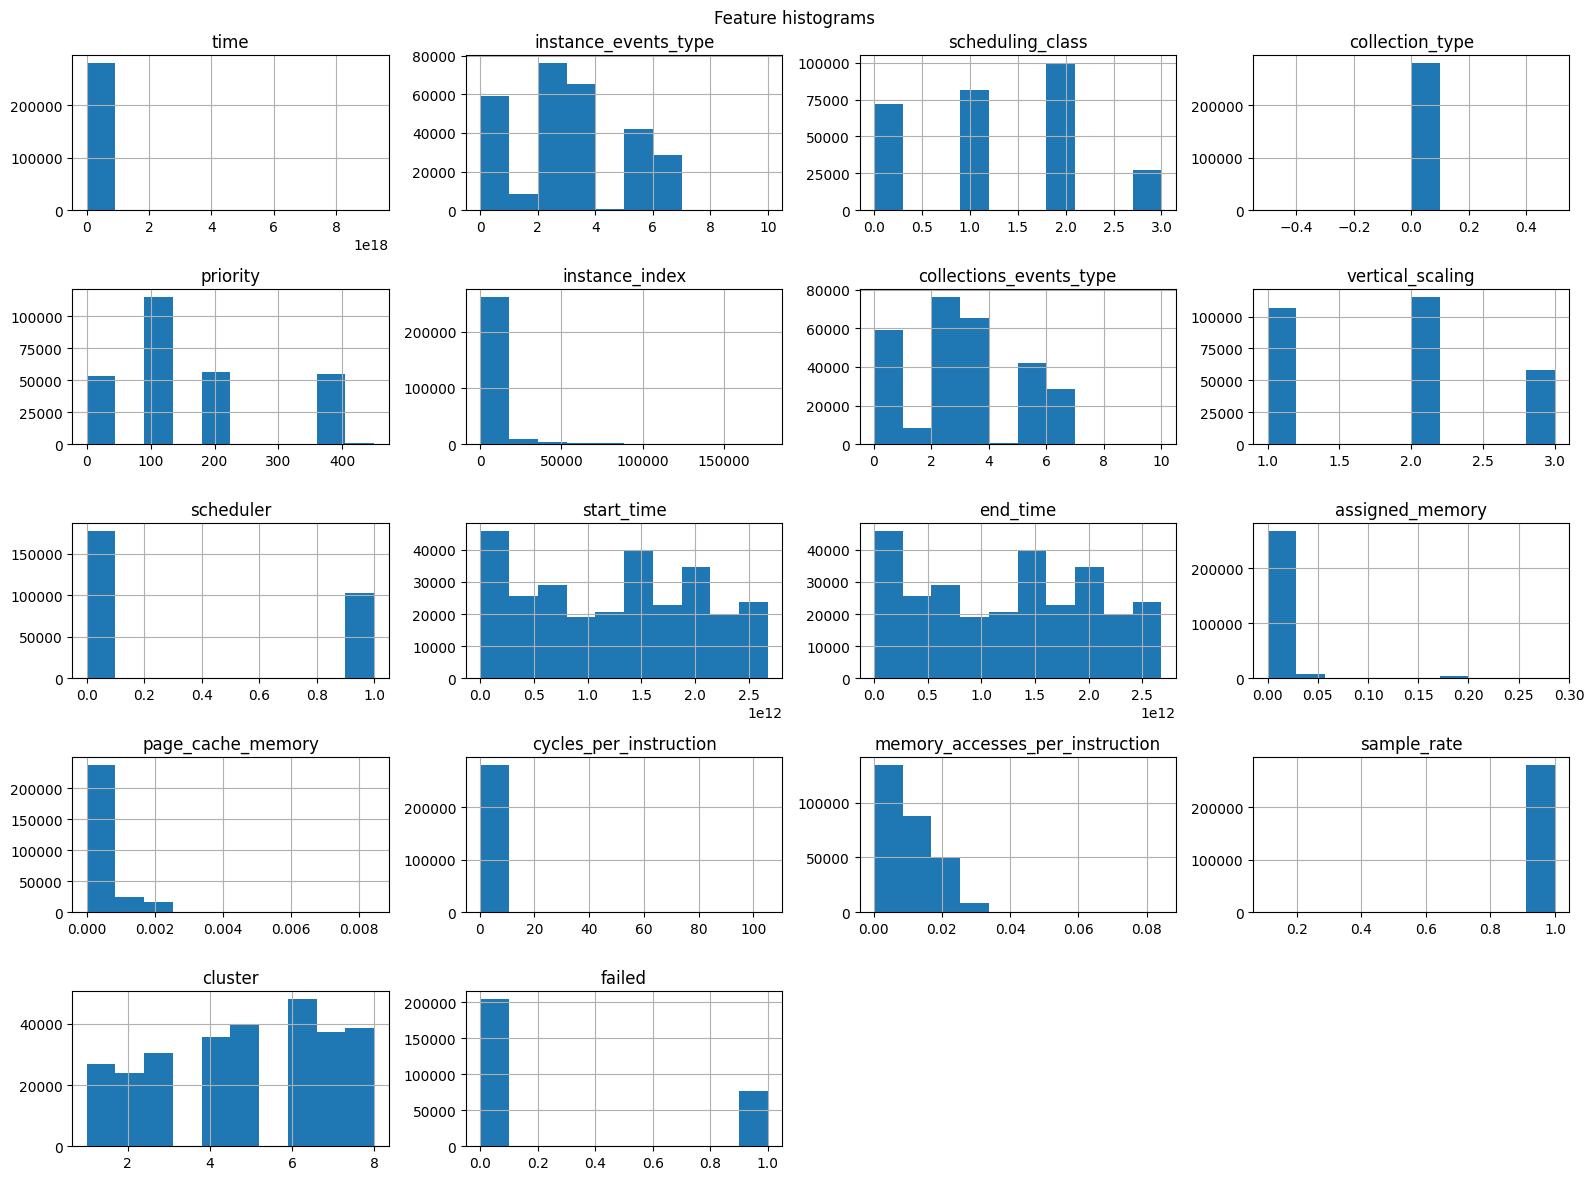

In [5]:
# Quick histograms (optional)
plt.figure(figsize=(14,8))
data.hist(figsize=(16,12))
plt.suptitle("Feature histograms")
plt.tight_layout()
plt.show()

In [6]:
#  Outlier winsorizing function (same approach you used)
def outlier_solver(DataFrame):
    df = DataFrame.copy()
    for i in df.columns:
        Q1 = df[i].quantile(0.25)
        Q3 = df[i].quantile(0.75)
        IQR = Q3 - Q1
        up_lim  = Q3 + 1.5 * IQR
        low_lim = Q1 - 1.5 * IQR
        df.loc[df[i] > up_lim, i]  = up_lim
        df.loc[df[i] < low_lim, i] = low_lim
    return df

data = outlier_solver(data)
print("After winsorizing outliers:", data.shape)

After winsorizing outliers: (280897, 18)


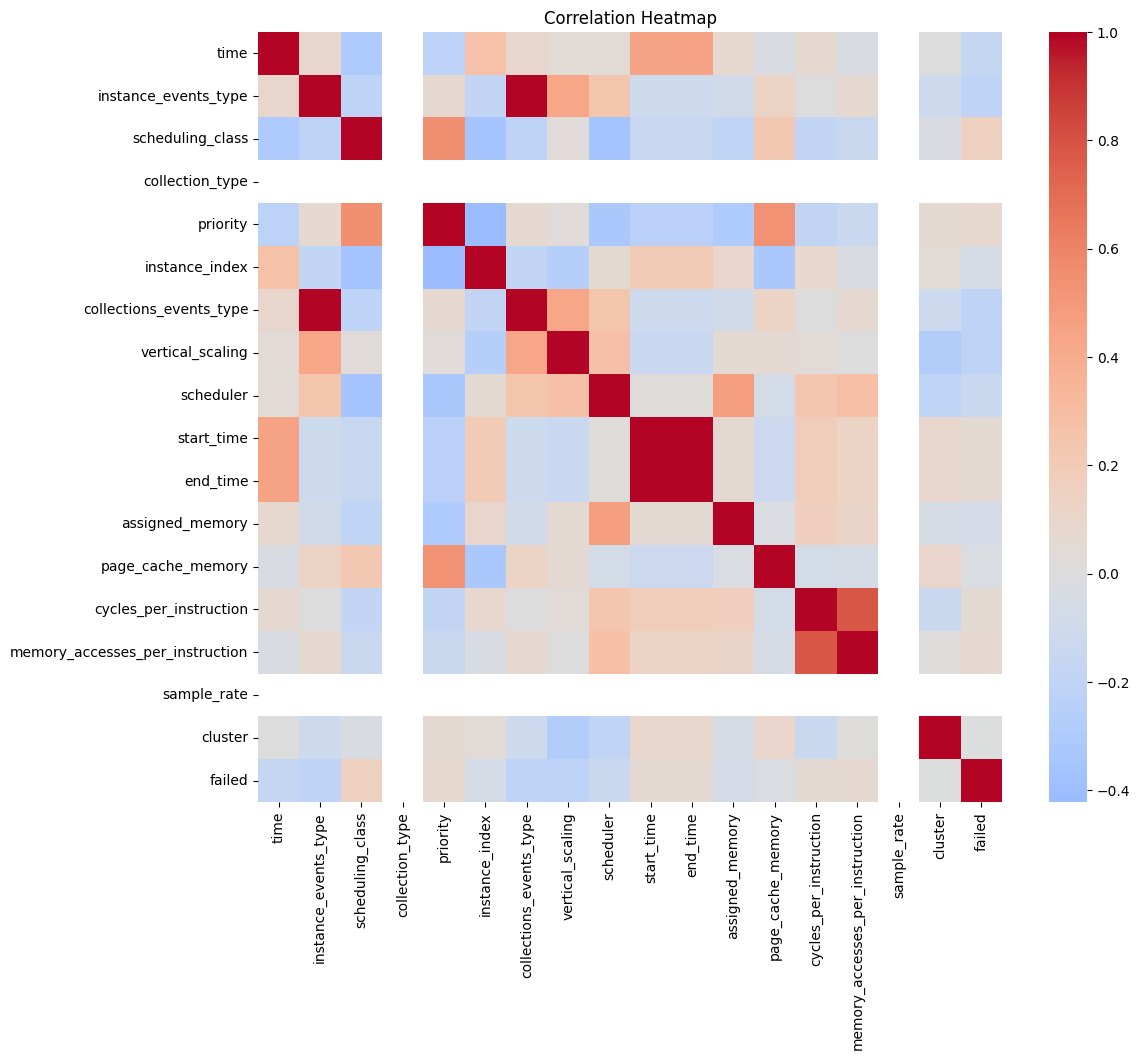

In [7]:
# Correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(data.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

In [8]:
# Drop specified columns if present
for col in ['collection_type','sample_rate']:
    if col in data.columns:
        data.drop(col, axis=1, inplace=True)
print("After dropping collection_type & sample_rate (if present):", data.shape)

After dropping collection_type & sample_rate (if present): (280897, 16)


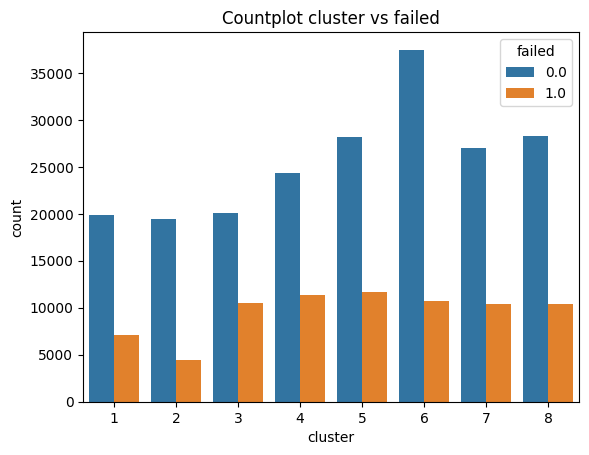

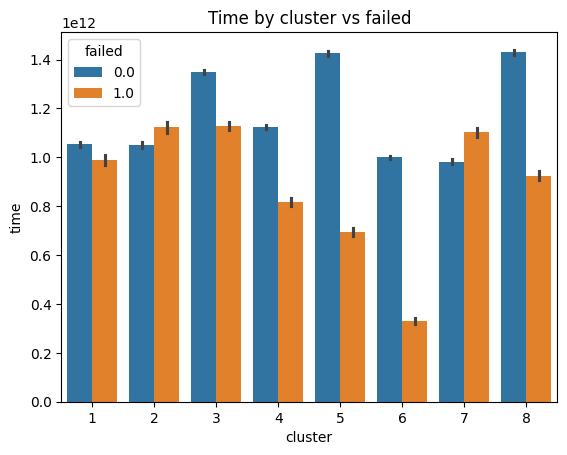

In [9]:
#  EDA visuals
if 'cluster' in data.columns and 'failed' in data.columns:
    try:
        sns.countplot(data=data, x="cluster", hue="failed")
        plt.title("Countplot cluster vs failed")
        plt.show()
    except Exception as e:
        print("Countplot error (maybe many classes):", e)

    try:
        sns.barplot(data=data, x="cluster", y="time", hue="failed")
        plt.title("Time by cluster vs failed")
        plt.show()
    except Exception as e:
        print("Barplot error (maybe large classes):", e)

In [10]:
#  Prepare X and y
X = data.drop(['cluster','failed'], axis=1, inplace=False)
y_cat = keras.utils.to_categorical(data.loc[:,'cluster'])
print("X shape:", X.shape, "y (one-hot) shape:", y_cat.shape)

# Train/validation split as in original (90%-10%)
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y_cat, train_size=0.9, random_state=42, shuffle=True
)

X shape: (280897, 14) y (one-hot) shape: (280897, 9)


In [11]:
# Scale features (important for NN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

input_shape  = [X.shape[1]]
output_shape = y_cat.shape[1]
print("Input shape:", input_shape, "Output shape (num classes):", output_shape)

Input shape: [14] Output shape (num classes): 9


In [12]:
# Build model
model = keras.Sequential([
    layers.BatchNormalization(input_shape=input_shape),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.15),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.15),

    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(output_shape, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 14)             │            56 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,577 (346.00 KB)

 Trainable params: 87,205 (340.64 KB)

 Non-trainable params: 1,372 (5.36 KB)

In [13]:
# Optionally visualize model (may require graphviz)
try:
    plot_model(model, show_shapes=True)
except:
    pass

In [14]:
# Compile and add callbacks: EarlyStopping + ModelCheckpoint
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [15]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8, min_delta=0.001, restore_best_weights=True
)
checkpoint = keras.callbacks.ModelCheckpoint(
    'best_keras_model.h5', monitor='val_loss', save_best_only=True
)

# batch_size but fallback if OOM
requested_batch = 10000
batch_size = requested_batch
epochs = 50

In [16]:
# Try to fit, batch size if OOM or other memory issue
trained = False
try:
    history = model.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        batch_size=batch_size,
        epochs=epochs,
        callbacks=[early_stopping, checkpoint],
        verbose=1
    )
    trained = True
except Exception as e:
    print(f"Training with batch_size={batch_size} failed: {e}")
    print("Retrying with batch_size=512")
    batch_size = 512
    history = model.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        batch_size=batch_size,
        epochs=epochs,
        callbacks=[early_stopping, checkpoint],
        verbose=1
    )
    trained = True

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.2389 - loss: 2.2885

26/26 ━━━━━━━━━━━━━━━━━━━━ 23s 394ms/step - accuracy: 0.2421 - loss: 2.2776 - val_accuracy: 0.4930 - val_loss: 1.9220
Epoch 2/50
24/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4930 - loss: 1.5185

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4958 - loss: 1.5111 - val_accuracy: 0.5460 - val_loss: 1.6367
Epoch 3/50
21/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5695 - loss: 1.2945

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5719 - loss: 1.2857 - val_accuracy: 0.6096 - val_loss: 1.3788
Epoch 4/50
23/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6117 - loss: 1.1553

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6129 - loss: 1.1516 - val_accuracy: 0.6494 - val_loss: 1.1565
Epoch 5/50
21/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6455 - loss: 1.0578

...

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8844 - loss: 0.3560 - val_accuracy: 0.9440 - val_loss: 0.1776
Epoch 46/50
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8838 - loss: 0.3575

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8838 - loss: 0.3574 - val_accuracy: 0.9464 - val_loss: 0.1737
Epoch 47/50
20/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8866 - loss: 0.3512

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8865 - loss: 0.3515 - val_accuracy: 0.9479 - val_loss: 0.1713
Epoch 48/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8877 - loss: 0.3499 - val_accuracy: 0.9466 - val_loss: 0.1719
Epoch 49/50
22/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8887 - loss: 0.3449

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8887 - loss: 0.3448 - val_accuracy: 0.9495 - val_loss: 0.1671
Epoch 50/50
21/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8896 - loss: 0.3420

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8896 - loss: 0.3420 - val_accuracy: 0.9484 - val_loss: 0.1654


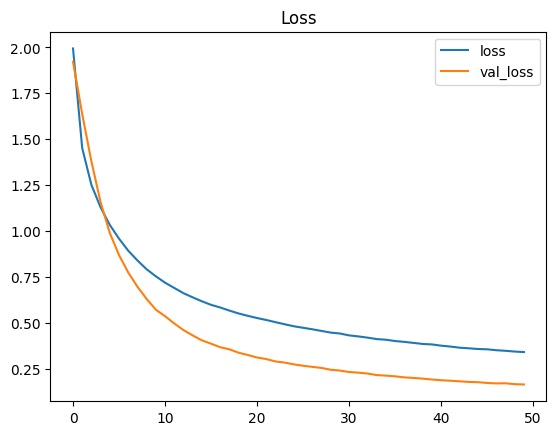

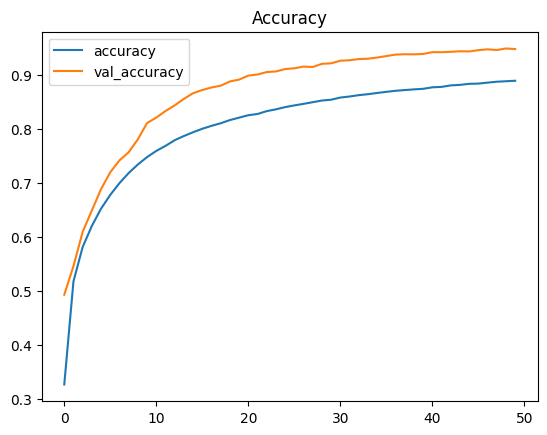

In [17]:
# Plot training history
history_df = pd.DataFrame(history.history)
if 'loss' in history_df.columns:
    history_df[['loss','val_loss']].plot(title='Loss')
if 'accuracy' in history_df.columns:
    history_df[['accuracy','val_accuracy']].plot(title='Accuracy')
plt.show()

In [18]:
#  Load best model weights (ModelCheckpoint saved it) and evaluate
try:
    model.load_weights('best_keras_model.h5')
    print("Loaded best_keras_model.h5 weights.")
except Exception as e:
    print("Could not load checkpoint (maybe not saved). Using current weights.", e)

Loaded best_keras_model.h5 weights.


In [19]:
#  Predictions on validation set
y_pred_proba = model.predict(X_valid)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_valid, axis=1)

#  Metrics requested
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

# Regression-like metrics on class indices
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("\n=== Evaluation Metrics ===")
print(f"RMSE (on class indices): {rmse:.4f}")
print(f"MAE  (on class indices): {mae:.4f}")
print(f"R^2  (on class indices): {r2:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall    (weighted): {recall:.4f}")
print(f"F1-score  (weighted): {f1:.4f}")

878/878 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step

=== Evaluation Metrics ===
RMSE (on class indices): 0.7298
MAE  (on class indices): 0.1446
R^2  (on class indices): 0.8882
Precision (weighted): 0.9485
Recall    (weighted): 0.9484
F1-score  (weighted): 0.9484


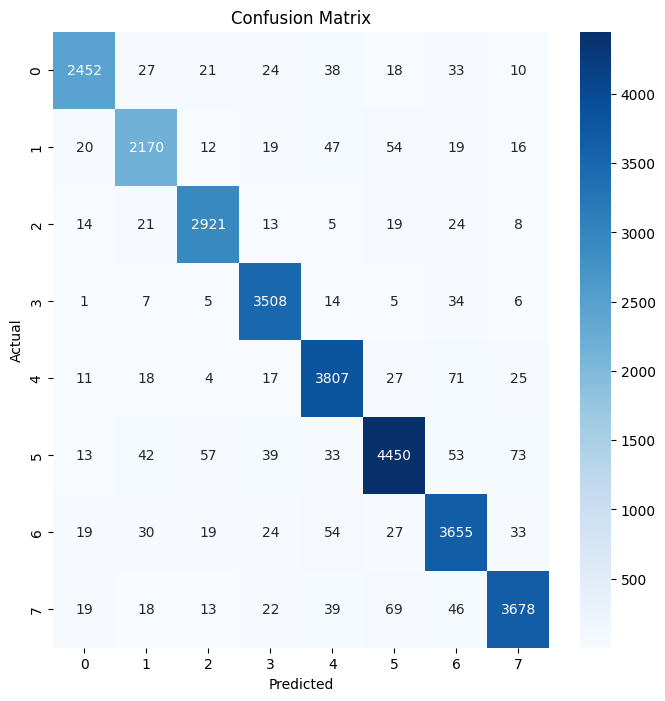

In [20]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

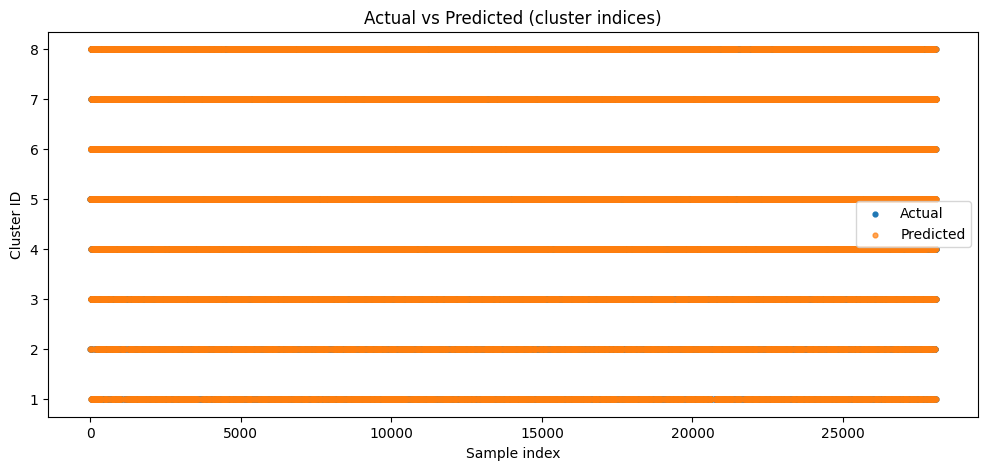

In [21]:
# Actual vs Predicted plot (class indices)
plt.figure(figsize=(12,5))
plt.scatter(range(len(y_true)), y_true, label='Actual', s=12)
plt.scatter(range(len(y_pred)), y_pred, label='Predicted', s=12, alpha=0.7)
plt.legend()
plt.title("Actual vs Predicted (cluster indices)")
plt.xlabel("Sample index")
plt.ylabel("Cluster ID")
plt.show()

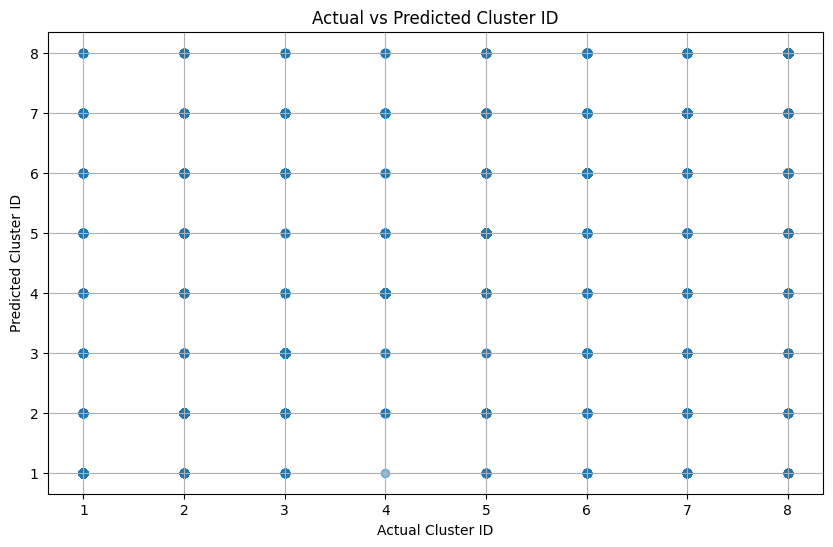

In [25]:
plt.figure(figsize=(10, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.xlabel("Actual Cluster ID")
plt.ylabel("Predicted Cluster ID")
plt.title("Actual vs Predicted Cluster ID")
plt.grid(True)
plt.show()

In [22]:
# Manual ICE-like plot for one feature
# Pick a feature index to analyze (0 = first feature). You can change this index.
feature_idx = 0
feature_name = X.columns[feature_idx]

# Use a copy of validation features (not scaled back) - but our X_valid is scaled; it's fine to use scaled values
X_valid_copy = X_valid.copy()
n_points = 25
vals = np.linspace(np.percentile(X_valid_copy[:, feature_idx], 5),
                   np.percentile(X_valid_copy[:, feature_idx], 95), n_points)


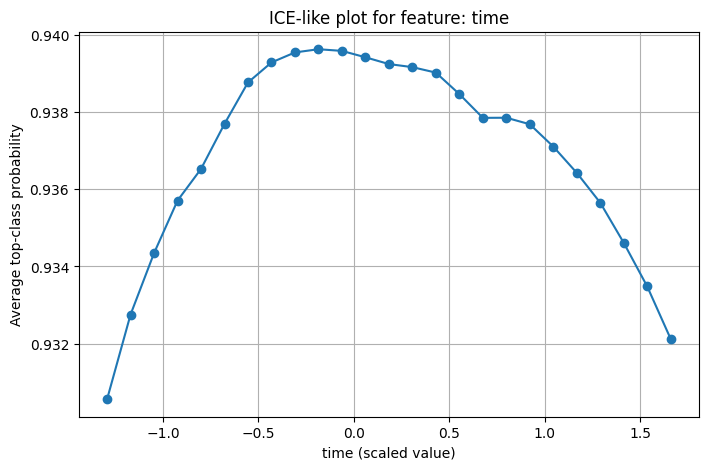

In [23]:
avg_top_probs = []
for v in vals:
    X_temp = X_valid_copy.copy()
    X_temp[:, feature_idx] = v
    probs = model.predict(X_temp, verbose=0)
    top_prob = probs.max(axis=1)  # per-sample top-class prob
    avg_top_probs.append(top_prob.mean())

plt.figure(figsize=(8,5))
plt.plot(vals, avg_top_probs, marker='o')
plt.xlabel(f"{feature_name} (scaled value)")
plt.ylabel("Average top-class probability")
plt.title(f"ICE-like plot for feature: {feature_name}")
plt.grid(True)
plt.show()


Running SHAP (this may take time). Using small subsets...


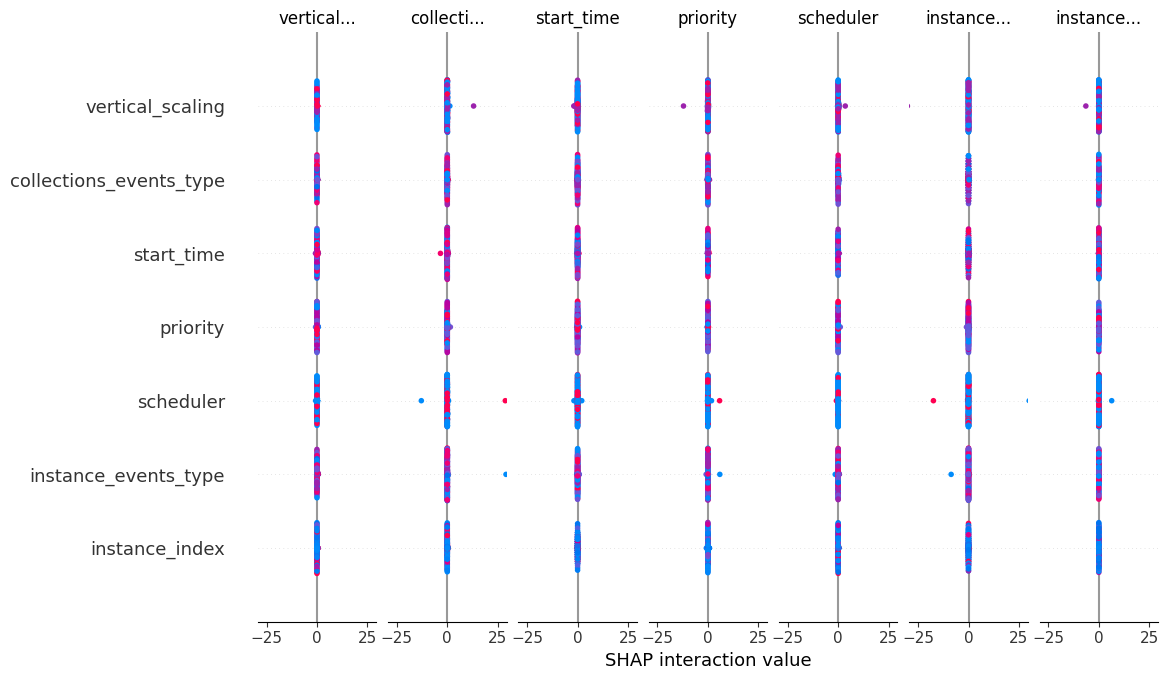


Notebook run complete.


In [24]:
# SHAP explanation (small sample)
# NOTE: DeepExplainer + Keras can be heavy. We use a small subset to avoid memory issues.
try:
    print("\nRunning SHAP (this may take time). Using small subsets...")
    small_train = X_train[:200] if X_train.shape[0] > 200 else X_train
    small_valid = X_valid[:200] if X_valid.shape[0] > 200 else X_valid

    # Use GradientExplainer or DeepExplainer depending on TF version - try DeepExplainer
    explainer = shap.DeepExplainer(model, small_train)
    shap_values = explainer.shap_values(small_valid)

    # shap_values is a list per class; create a summary_plot for all classes combined by summing magnitude
    # For multi-class, shap.summary_plot accepts list-of-arrays; it will plot per-class separately unless aggregated.
    shap.summary_plot(shap_values, small_valid, feature_names=X.columns)
except Exception as e:
    print("SHAP failed or was too heavy on this environment:", e)

print("\nNotebook run complete.")

878/878 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


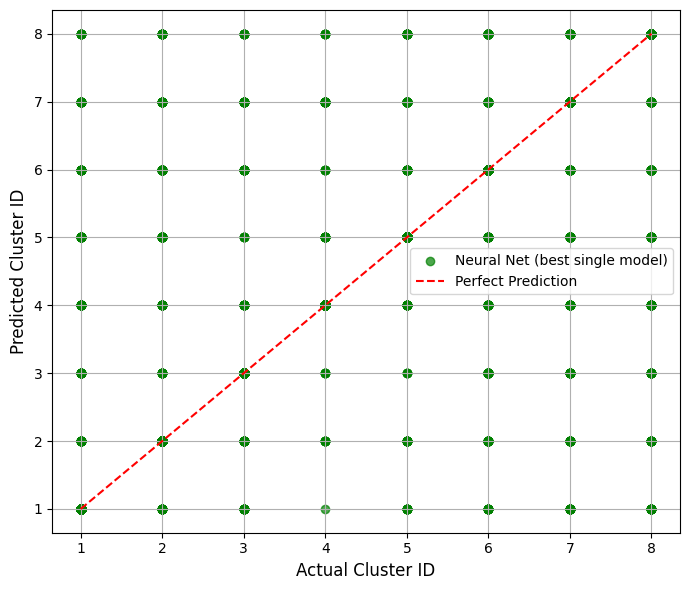

In [28]:
import matplotlib.pyplot as plt

y_pred_probs = model.predict(X_valid)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Convert y_valid from one-hot encoding to class indices
y_valid_classes = np.argmax(y_valid, axis=1)


plt.figure(figsize=(7,6))

# Plot neural net
plt.scatter(y_valid_classes, y_pred_classes, alpha=0.7, label="Neural Net (best single model)", color="green")

# Perfect prediction line
plt.plot([y_valid_classes.min(), y_valid_classes.max()], [y_valid_classes.min(), y_valid_classes.max()], 'r--', label="Perfect Prediction")

plt.xlabel("Actual Cluster ID", fontsize=12)
plt.ylabel("Predicted Cluster ID", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()